# 05 — Composite limits, no atmosphere

**Paper element.** Supplemental Material, Supplementary Limit Figures: figure
`05_composite_noatm`, the companion scan with atmospheric attenuation switched off.

The counterpart to [`01`](01_limit_contour.ipynb),
with overburden attenuation **switched off**: the DM velocity distribution is the
bare standard halo model for every $(m_{\rm DM}, \alpha_n)$ (no attenuation ODE),
so there is **no atmospheric ceiling** — exclusion runs up to $\alpha_n = 1$. This
isolates what the atmosphere costs (compare the top edge here with the attenuated
ceiling in notebook 01, which reads the same scan with attenuation on).

**"Composite" here means the three sensor modes combined**: a point is excluded
if *any* mode excludes it (element-wise max of the extremeness). It has nothing
to do with the *composite-dark-matter benchmark* of the Letter (a single 20 µm
slice in a $m_d$, $\sigma_{\chi n}$ parameterisation); no quantity from that
model appears here. Shown per mediator range,
at the same fiducials otherwise — $q_\text{min}$ = 1 TeV/$c$, per-mode
efficiency, candidates `data_mode{n}.txt`, $T$ = 219.66 h.

**Dark matter fraction.** This notebook opens **file B** of the release, which
carries exactly one hypothesis: $f_\mathrm{DM}$ = 0.1 with attenuation off, the
plane the Letter's composite cross-section benchmark is quoted on. Notebook 01,
which draws the attenuated counterpart, opens file A at $f_\mathrm{DM}$ = 1.

**The right-hand edge.** The impact-parameter integral is uncapped in this
release, so nothing in the surfaces closes the massless contour on the right; it
runs to the Planck mass. The release closes it with a halo flux cut — the mass
beyond which fewer than $N_\text{req} = 3$ particles pass within 10 cm of the
sensor during the exposure, **an assumption** stored in the file's `m_cut_*`
attributes. At $f_\mathrm{DM}$ = 0.1 that is a factor of ten lower than in
notebook 01: $m_\text{cut} = 6.11\times10^{13}$ GeV. It is drawn below; nothing
to its right is a claim.

Surfaces: the atmosphere-off plane of the data release, selected with the
back-compatible `group='noatm'` spelling (in the current cube layout that is the
`atmosphere = 0` value of the `atmosphere` axis, not a separate group, and in
file B it is the only value on that axis); composite = element-wise max of the
three modes' extremeness.

In [1]:
%matplotlib inline
import os as _os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

from luhdm import release

for _d in ("png", "svg", "pdf"):
    _os.makedirs(_d, exist_ok=True)
def save_figure(fig, name, **kw):
    # every figure lands in png/, svg/, and pdf/ with a notebook-number
    # prefix, stamped with the data-release version that produced it so
    # a figure always names its cube
    fig.text(0.995, 0.004, f"POLONAISE UHDM data release {rel.version_tag}",
             ha="right", va="bottom", fontsize=6, color="#9a9a9a")
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)

MODES = (1, 2, 3)
CONF = 0.95
M_PLANCK = 1.22e19
G_PER_GEV = 1.78266192e-24   # 1 GeV/c^2 in grams

RANGES = ["massless", "2mm", "200um", "20um"]  # the physics slices; the axis
                                               # also holds a 200 m
                                               # convergence check, not drawn
LABEL = {"massless": "massless", "2m": "2 m", "2cm": "2 cm", "2mm": "2 mm",
         "200um": "200 µm", "20um": "20 µm", "10um": "10 µm", "2um": "2 µm"}
STYLE = {"massless": "solid", "2m": (0, (5, 1)), "2cm": (0, (1, 1)),
         "2mm": (0, (3, 5, 1, 5)), "200um": (0, (5, 5)), "20um": (0, (3, 1, 1, 1)),
         "10um": (0, (1, 3)), "2um": (0, (3, 5, 1, 5, 1, 5))}
# colour ramp over ranges (long range dark -> short range light), viridis
RCOLOR = {t: plt.cm.viridis(x) for t, x in zip(RANGES, np.linspace(0.05, 0.85, len(RANGES)))}

# File B of the released pair: f_DM = 0.1 with attenuation OFF, which is this
# notebook's whole subject. The internal full-lambda cube stays on
# luhdm.release.DEFAULT_PATH for the paper-figure scripts.
rel = release.open_release("../release/luhdm_datarelease_v8_B_f0p1_noatm.h5")

# the halo flux cut that closes every contour on the right, read from the file
# rather than typed in: file B stores it at its own f_DM = 0.1.
M_CUT = next(float(v) for k, v in rel.attrs.items()
             if k.startswith("m_cut_") and k.endswith("_gev"))
N_REQ = float(rel.attrs["m_cut_n_transits_required"])

def composite(tag):
    """(ms, alphas, max-over-modes extremeness) for one range, from /noatm."""
    return (rel.axes_noatm.mass_gev, rel.axes.alpha_n,
            rel.composite("extremeness", lam=tag, group="noatm"))

## Status

In [2]:
for tag in RANGES:
    ms, al, ext = composite(tag)
    frac = f"{(ext >= CONF).mean():.3f}"
    # /noatm completeness: fraction of cells with a valid status (not exception=1)
    comp = " ".join(
        f"m{n}:{(rel.mass_plane('status', mode=n, lam=tag, group='noatm') != 1).mean():.2f}"
        for n in MODES)
    print(f"{tag:>9} | /noatm complete {comp} | composite excluded {frac}")
print(f"\nflux cut m_cut = {M_CUT:.3g} GeV at f_DM = {rel.f_dm_values[0]:g} "
      f"(N_req = {N_REQ:g} transits within {rel.attrs['m_cut_b_cap_m']:g} m -- "
      f"an assumption; see release/README.md section 5.4)")

 massless | /noatm complete m1:1.00 m2:1.00 m3:1.00 | composite excluded 0.532
      2mm | /noatm complete m1:1.00 m2:1.00 m3:1.00 | composite excluded 0.286
    200um | /noatm complete m1:1.00 m2:1.00 m3:1.00 | composite excluded 0.192
     20um | /noatm complete m1:1.00 m2:1.00 m3:1.00 | composite excluded 0.070

flux cut m_cut = 6.11e+13 GeV at f_DM = 0.1 (N_req = 3 transits within 0.1 m -- an assumption; see release/README.md section 5.4)


## Three-mode exclusion — no atmosphere

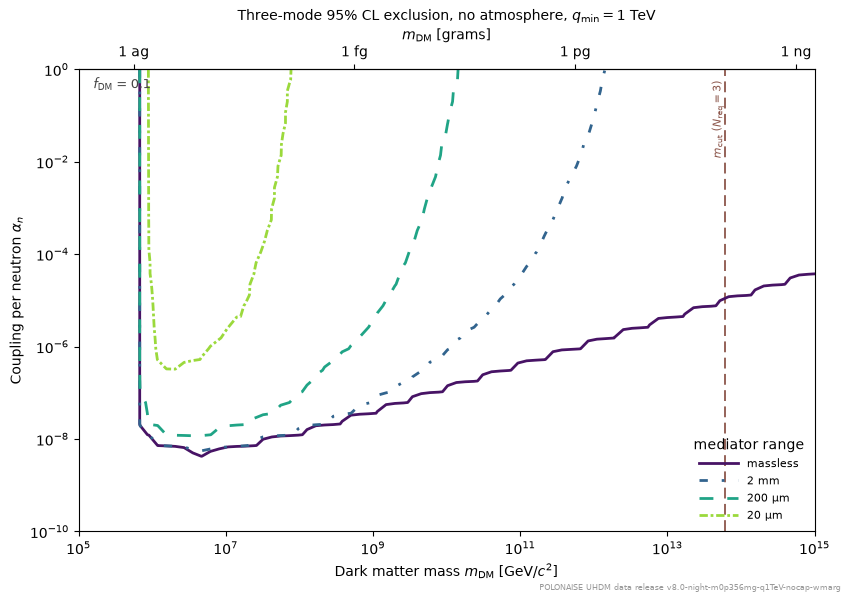

In [3]:
XMAX = 1e15   # past the flux cut; the massless contour itself does not close
fig, ax = plt.subplots(figsize=(8.5, 6))
xmin = M_PLANCK
drawn = []
for tag in RANGES:
    c = composite(tag)
    if c is None:
        continue
    ms, al, ext = c
    if not (ext >= CONF).any():
        continue
    xmin = min(xmin, ms.min())
    drawn.append(tag)
    ax.contour(ms, al, ext, levels=[CONF], colors=[RCOLOR[tag]],
               linestyles=[STYLE[tag]], linewidths=2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(xmin, XMAX); ax.set_ylim(1e-10, 1.0)
ax.set_xlabel(r"Dark matter mass $m_{\rm DM}$ [GeV/$c^2$]")
ax.set_ylabel(r"Coupling per neutron $\alpha_n$")
sec = ax.secondary_xaxis("top",
                         functions=(lambda x: x*G_PER_GEV, lambda g: g/G_PER_GEV))
sec.set_xlabel(r"$m_{\rm DM}$ [grams]")
_gt = [1e-18, 1e-15, 1e-12, 1e-9, 1e-6]; _gl = ["1 ag", "1 fg", "1 pg", "1 ng", "1 µg"]
_keep = [(t, l) for t, l in zip(_gt, _gl) if xmin*G_PER_GEV <= t <= XMAX*G_PER_GEV]
sec.set_xticks([t for t, _ in _keep]); sec.set_xticklabels([l for _, l in _keep])
sec.xaxis.set_minor_locator(plt.NullLocator())
ax.axvline(M_CUT, color="#8c564b", lw=1.3, ls=(0, (6, 3)), zorder=1)
ax.text(M_CUT, 0.985, r"$m_{\rm cut}$ ($N_{\rm req}=3$) ", color="#8c564b",
        fontsize=8, ha="right", va="top", rotation=90,
        transform=ax.get_xaxis_transform())
ax.set_title("Three-mode 95% CL exclusion, no atmosphere, $q_{\\rm min}=1$ TeV",
             fontsize=10)
# State the abundance plane in the figure: this scan reads the loader
# default f_DM = 0.1, not the f_DM = 1 the coupling limits are quoted at.
ax.text(0.02, 0.98, r"$f_{\rm DM}$ = 0.1", transform=ax.transAxes,
        ha="left", va="top", fontsize=9, color="#444444")
handles = [Line2D([], [], color=RCOLOR[t], lw=2, linestyle=STYLE[t], label=LABEL[t])
           for t in RANGES if t in drawn]
ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=8,
          handlelength=3.5,
          title="mediator range")
fig.tight_layout(); save_figure(fig, "05_composite_noatm"); plt.show()